In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: str
    result: str

In [3]:
def show_equation(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    result = ""

    if (a==0 and b==0 and c==0):
        result = "0"
    elif (b==0 and c==0):
        result = f"{a}X^2"
    elif (b==0 and c>0):
        result = f"{a}X^2 + {c}"
    elif (b==0 and c<0):
        result = f"{a}X^2 - {c*-1}"
    elif (c==0 and b>0):
        result = f"{a}X^2 + {b}X"
    elif (c==0 and b<0):
        result = f"{a}X^2 - {b*-1}X"
    elif (b>0 and c>0):
        result = f"{a}X^2 + {b}X + {c}"
    elif (b>0 and c<0):
        result = f"{a}X^2 + {b}X - {c*-1}"
    elif (b<0 and c>0):
        result = f"{a}X^2 - {b*-1}X + {c}"
    else:
        result = f"{a}X^2 - {b*-1}X - {c*-1}"

    print(result)
    return {"equation" : result}

In [4]:
def calculate_discriminant(state: QuadState):
    discriminant = state['b']**2 - 4*state['a']*state['c']
    return {"discriminant" : discriminant}

In [5]:
def real_root(state: QuadState):
    root1 = (-state['b'] + state['discriminant'])/(2*state['a'])
    root2 = (-state['b'] - state['discriminant'])/(2*state['a'])

    result = f"The roots are {root1} and {root2}"
    return {"result": result}

In [6]:
def repeated_root(state: QuadState):
    root = (-state['b'])/(2*state['a'])
    
    result = f"Only 1 repeated root {root}"

    return {"result": result}

In [7]:
def no_real_root(state: QuadState):
    result = "no real roots"
    return {"result": result}

In [8]:
def check_discriminant(state: QuadState) -> Literal["real_root", "no_real_root", "repeated_root"]:
    if state["discriminant"]==0:
        return "repeated_root"
    elif state["discriminant"]>0:
        return "real_root"
    else:
        return "no_real_root"

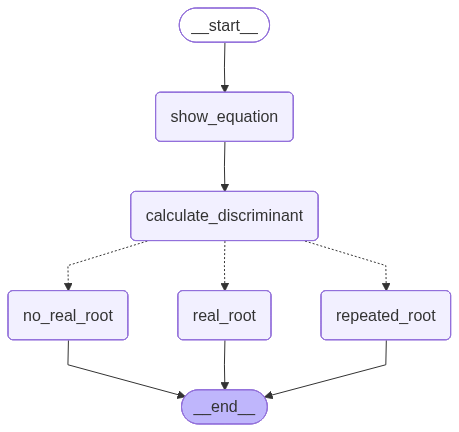

In [10]:
graph = StateGraph(QuadState)

# add nodes
graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_root", real_root)
graph.add_node("repeated_root", repeated_root)
graph.add_node("no_real_root", no_real_root)

# add edges
graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant", check_discriminant)
graph.add_edge("real_root", END)
graph.add_edge("repeated_root", END)
graph.add_edge("no_real_root", END)

# compile graph
workflow = graph.compile()
workflow

In [12]:
initial_state = {
    "a" : -2,
    "b" : -2,
    "c" : 3
}

final_state = workflow.invoke(initial_state)
final_state

-2X^2 - 2X + 3


{'a': -2,
 'b': -2,
 'c': 3,
 'equation': '-2X^2 - 2X + 3',
 'discriminant': 28,
 'result': 'The roots are -7.5 and 6.5'}